---
## 1. Setup & Imports

In [1]:
# Standard data science stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Project root for imports
import sys, os
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath('.'))))

---
## 2. Load Clean Data

Load the cleaned DataFrame from CleanData. This is the starting point for feature engineering.

In [2]:
import sys
sys.path.insert(0, r'C:\Users\ycode\Documents\Ames-Housing-ML')

from src.preprocess import CleanData

cleaner = CleanData()
df = cleaner.clean_df

print(f'Shape: {df.shape}')
print(f'Columns: {len(df.columns)}')

# Confirm no missing values
missing = df.isna().sum().sum()
print(f'Missing values: {missing}')
if missing > 0:
    print('WARNING: missing values found!')
    print(df.isna().sum()[df.isna().sum() > 0].to_string())

No duplicates
Shape: (2919, 70)
Columns: 70
Missing values: 12
MSZoning        4
Exterior1st     1
Exterior2nd     1
BsmtHalfBath    2
KitchenQual     1
GarageCars      1
GarageArea      1
SaleType        1


---
## 3. Create New Numeric Features

Add derived features: TotalSF, Age, RemodAge, TotalBath, TotalPorchSF, IsNew, HasPool, HasMasonryVeneer.

Before feature creation: (2919, 70)
After feature creation: (2919, 78)

=== New Features — Correlation with SalePrice ===
SalePrice           1.000000
TotalSF             0.618720
TotalBath           0.460999
HasMasonryVeneer    0.269869
IsNew               0.171961
TotalPorchSF        0.155796
HasPool             0.075017
RemodAge           -0.350032
Age                -0.362066


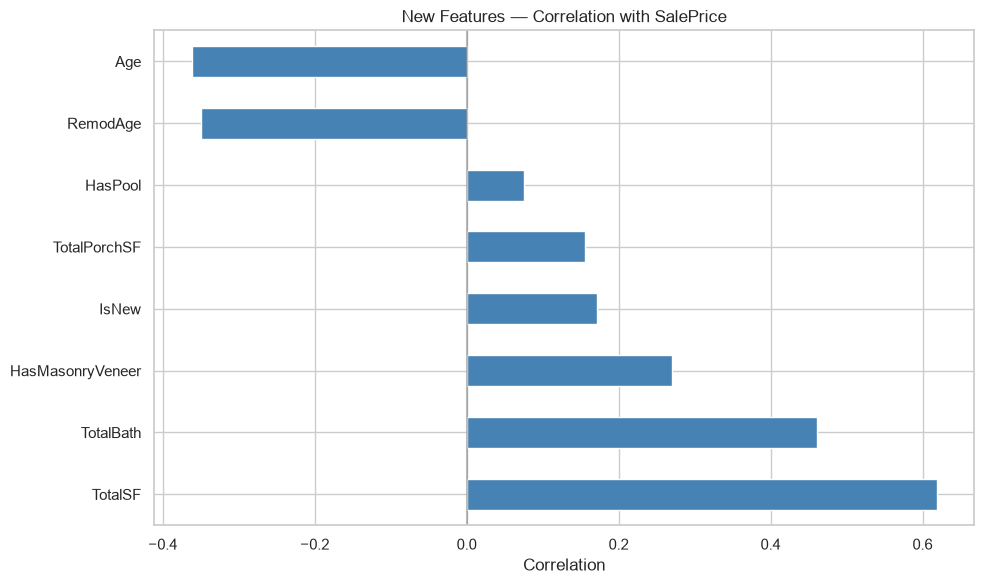

In [3]:
from src.features import add_numeric_features

print('Before feature creation:', df.shape)
df = add_numeric_features(df)
print('After feature creation:', df.shape)

# List the new features
new_features = ['TotalSF', 'Age', 'RemodAge', 'TotalBath',
                'TotalPorchSF', 'IsNew', 'HasPool', 'HasMasonryVeneer']

print('\n=== New Features — Correlation with SalePrice ===')
new_corr = df[new_features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
print(new_corr.to_string())

# Bar chart of new feature correlations
plt.figure(figsize=(10, 6))
new_corr.drop('SalePrice').plot(kind='barh', color='steelblue')
plt.title('New Features — Correlation with SalePrice')
plt.xlabel('Correlation')
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

---
## 4. Encode Ordinal Categorical Features

Encode ordinal columns as integers: ExterQual, ExterCond, BsmtQual, BsmtCond, HeatingQC, KitchenQual, GarageQual, GarageCond.

Show value distributions before and after encoding to verify correctness.

In [4]:
from src.features import encode_ordinal_features

# Before encoding
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'GarageQual', 'GarageCond']

print('=== Ordinal Columns — Before Encoding ===')
for col in ordinal_cols:
    if col in df.columns:
        print(f'\n--- {col} ---')
        print(df[col].value_counts().to_string())
        print(f'Missing: {df[col].isna().sum()}')

# Apply encoding
df = encode_ordinal_features(df)

print('\n=== Ordinal Columns — After Encoding ===')
for col in ordinal_cols:
    if col in df.columns:
        print(f'\n{col}:')
        print(f'  Unique values: {sorted(df[col].dropna().unique())}')
        print(f'  Corr with SalePrice: {df[col].corr(df["SalePrice"]):.3f}')
        print(f'  Missing: {df[col].isna().sum()}')

=== Ordinal Columns — Before Encoding ===

--- ExterQual ---
ExterQual
TA    1798
Gd     979
Ex     107
Fa      35
Missing: 0

--- ExterCond ---
ExterCond
TA    2538
Gd     299
Fa      67
Ex      12
Po       3
Missing: 0

--- BsmtQual ---
BsmtQual
TA            1283
Gd            1209
Ex             258
Fa              88
NoBasement      81
Missing: 0

--- BsmtCond ---
BsmtCond
TA            2606
Gd             122
Fa             104
NoBasement      82
Po               5
Missing: 0

--- HeatingQC ---
HeatingQC
Ex    1493
TA     857
Gd     474
Fa      92
Po       3
Missing: 0

--- KitchenQual ---
KitchenQual
TA    1492
Gd    1151
Ex     205
Fa      70
Missing: 1

--- GarageQual ---
GarageQual
TA          2604
NoGarage     159
Fa           124
Gd            24
Po             5
Ex             3
Missing: 0

--- GarageCond ---
GarageCond
TA          2654
NoGarage     159
Fa            74
Gd            15
Po            14
Ex             3
Missing: 0

=== Ordinal Columns — After Encoding ===


---
## 5. One-Hot Encode Nominal Categorical Features

Encode nominal columns as dummy variables. Check shape after — one-hot creates many new columns.

In [5]:
from src.features import encode_nominal_features

nominal_cols = [
    'MSZoning', 'Neighborhood', 'BldgType', 'HouseStyle',
    'RoofStyle', 'Foundation', 'CentralAir', 'PavedDrive',
    'SaleType', 'SaleCondition', 'Electrical', 'Functional',
    'Exterior1st', 'Exterior2nd', 'MasVnrType'
]

nominal_cols = [c for c in nominal_cols if c in df.columns]
print(f'Nominal columns to encode ({len(nominal_cols)}):')
print(nominal_cols)

print(f'\nShape before encoding: {df.shape}')
df = encode_nominal_features(df, nominal_cols)
print(f'Shape after encoding: {df.shape}')

# Show sample of dummy columns
dummy_cols = [c for c in df.columns
               if any(c.startswith(cat + '_') for cat in nominal_cols)]
print(f'\nTotal dummy columns: {len(dummy_cols)}')
print('First 20:')
print(dummy_cols[:20])

Nominal columns to encode (15):
['MSZoning', 'Neighborhood', 'BldgType', 'HouseStyle', 'RoofStyle', 'Foundation', 'CentralAir', 'PavedDrive', 'SaleType', 'SaleCondition', 'Electrical', 'Functional', 'Exterior1st', 'Exterior2nd', 'MasVnrType']

Shape before encoding: (2919, 78)
Shape after encoding: (2919, 185)

Total dummy columns: 122
First 20:
['MSZoning_C (all)', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Neighborhood_Blmngtn', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes']


---
## 6. Verify the Full Feature Set

Check shape, correlations of all features with target, identify strongest predictors.

No duplicates
No duplicates
=== SalePrice — Basic Stats ===
count      2919.000000
mean     180052.854647
std       57381.565721
min       34900.000000
25%      154795.084126
50%      176734.841494
75%      191895.744157
max      755000.000000
Name: SalePrice, dtype: float64

Zero values: 0
Negative values: 0


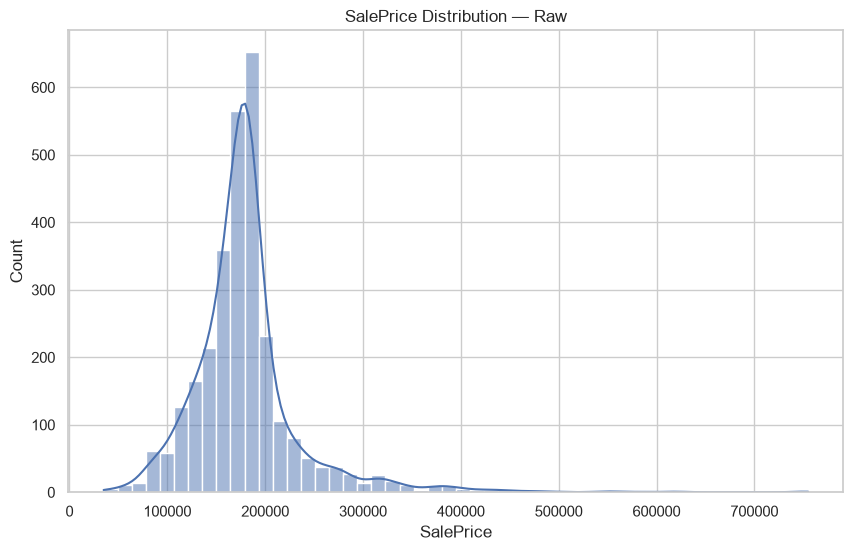


Skewness (raw SalePrice): 2.549


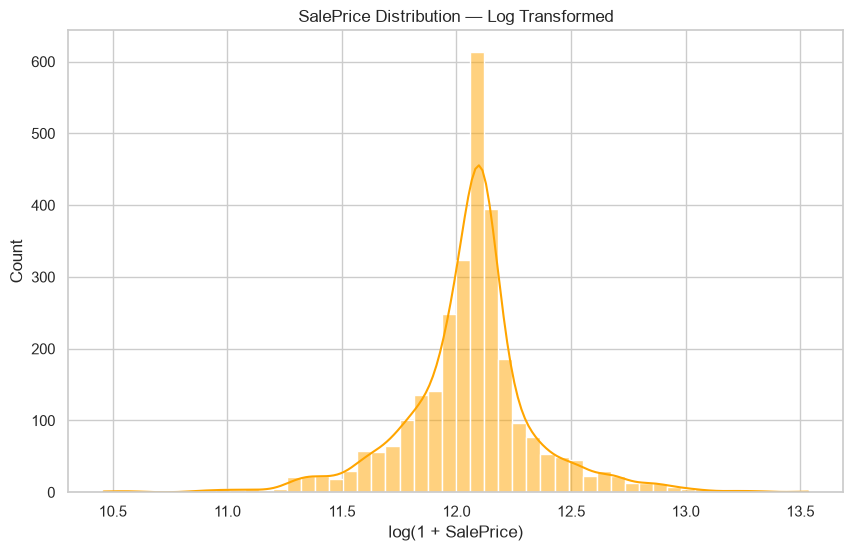

Skewness (log SalePrice): -0.150

→ Raw skewness: 2.549  →  Log skewness: -0.150
→ Log transform successfully normalized the distribution.
Numeric features: 176
Total features (including dummies): 186

=== Top 20 Correlations with SalePrice ===
SalePrice       1.000000
LogSalePrice    0.942008
TotalSF         0.618720
GrLivArea       0.588010
OverallQual     0.550911
TotRmsAbvGrd    0.469800
GarageCars      0.469249
ExterQual       0.467746
KitchenQual     0.466933
GarageArea      0.464809
1stFlrSF        0.462865
TotalBath       0.460999
TotalBsmtSF     0.453089
FullBath        0.433710
BsmtQual        0.395245
YearBuilt       0.362066
Fireplaces      0.353567
MasVnrArea      0.351883
YearRemodAdd    0.350032
HasFireplace    0.349652


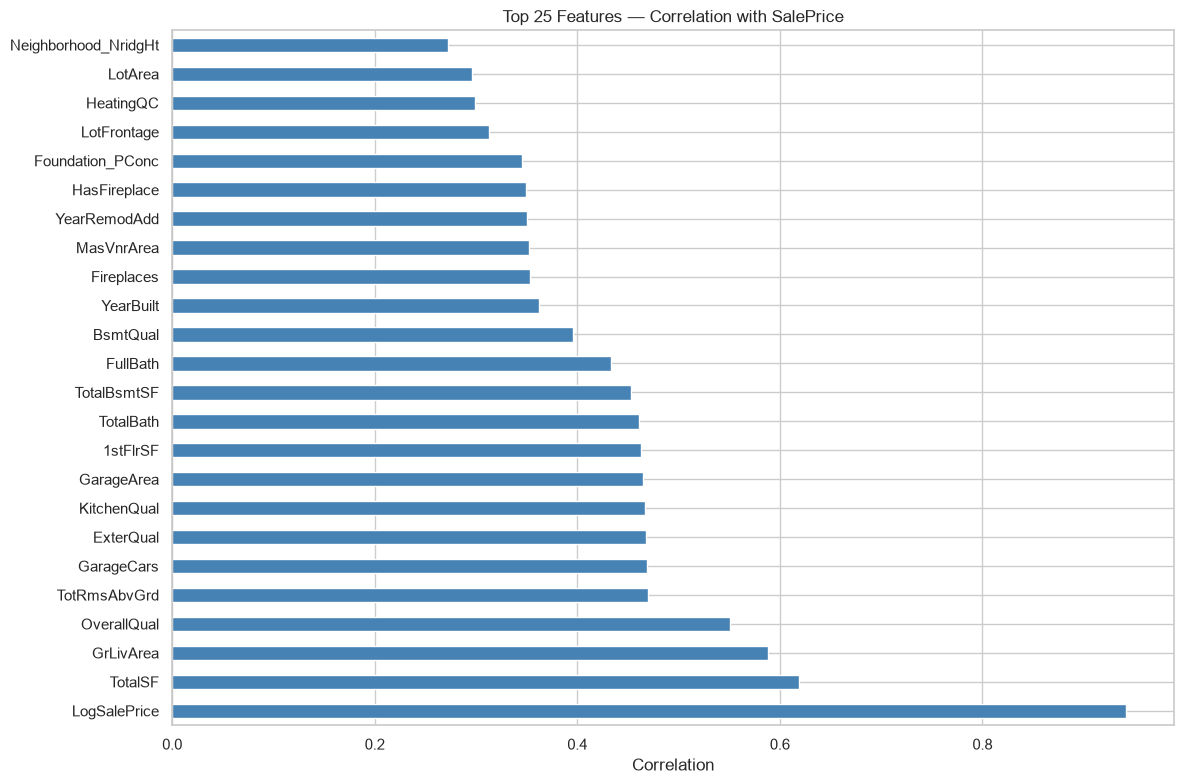


=== Top 15 Correlations with LogSalePrice ===
LogSalePrice    1.000000
SalePrice       0.942008
TotalSF         0.610667
GrLivArea       0.578486
OverallQual     0.563275
GarageCars      0.494292
TotalBath       0.487599
GarageArea      0.481480
KitchenQual     0.468213
TotRmsAbvGrd    0.468042
ExterQual       0.460119
FullBath        0.457031
1stFlrSF        0.453791
TotalBsmtSF     0.448106
BsmtQual        0.410425


In [6]:
import sys
sys.path.insert(0, r'C:\Users\ycode\Documents\Ames-Housing-ML\src')

from src.analysis import analyze_target

analyze_target(df)

# Numeric features only (for correlation)
numeric_features = df.select_dtypes(include=[np.number]).columns
print(f'Numeric features: {len(numeric_features)}')
print(f'Total features (including dummies): {len(df.columns)}')

# Correlation of all numeric features with SalePrice
print('\n=== Top 20 Correlations with SalePrice ===')
full_corr = df[numeric_features].corr()['SalePrice'].sort_values(ascending=False)
print(full_corr.head(20).to_string())

# Bar chart
plt.figure(figsize=(12, 8))
full_corr.head(25).drop('SalePrice', errors='ignore').plot(
    kind='barh', color='steelblue'
)
plt.title('Top 25 Features — Correlation with SalePrice')
plt.xlabel('Correlation')
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

# Correlation with LogSalePrice (for linear models)
print('\n=== Top 15 Correlations with LogSalePrice ===')
log_corr = df[numeric_features].corr()['LogSalePrice'].sort_values(ascending=False)
print(log_corr.head(15).to_string())

---
## 7. Check Multicollinearity

Find pairs of features with |r| > 0.8. High multicollinearity can cause issues for Linear Regression.

Also check for low-variance (nearly constant) features.

---
## 7b. Outlier Detection & Handling — GrLivArea

Identify GrLivArea outliers: houses with large living area (> 3500 sqft) but low sale price (< $300K).

These are the classic Ames outliers. Some are data errors (area recorded too high or price too low), others are unusual but real properties (large estate sold below market for personal reasons).

Decision framework:
- **Low OverallQual (≤ 4) + large area + low price** → likely data error → DELETE
- **High OverallQual (≥ 5) + large area + low price** → unusual but possibly real → KEEP, monitor
- **Expensive houses ($500K+)** → NOT outliers, just expensive → KEEP

The log transform on SalePrice already handles the skew from expensive houses.

In [7]:
# Identify the outliers
print('=== GrLivArea Outliers — Large Area, Low Price ===')
outliers = df[(df['GrLivArea'] > 3500) & (df['SalePrice'] < 300000)]
print(f'Count: {len(outliers)} houses\n')

if len(outliers) > 0:
    cols_to_show = ['Id', 'SalePrice', 'GrLivArea', 'OverallQual',
                    'YearBuilt', 'Neighborhood', 'HouseStyle']
    cols_to_show = [c for c in cols_to_show if c in df.columns]
    print(outliers[cols_to_show].to_string())

# Check for other potential outliers
print('\n=== Other Potential Outliers ===') # Most expensive houses (not outliers — just expensive)
expensive = df.nlargest(5, 'SalePrice')[['Id', 'SalePrice', 'GrLivArea', 'OverallQual']]
print('\nTop 5 most expensive houses (these are NOT outliers — keep them):')
print(expensive.to_string())

# Houses with extremely large LotArea
large_lot = df[df['LotArea'] > 20000][['Id', 'SalePrice', 'LotArea', 'GrLivArea', 'OverallQual']]
print(f'\nHouses with LotArea > 20000 sqft: {len(large_lot)}')
if len(large_lot) > 0:
    print(large_lot.to_string())

# Decision — which to delete?
print('\n=== Outlier Decision ===') # Delete houses where: GrLivArea > 3500 AND SalePrice < 300K AND OverallQual <= 4
# These are likely data entry errors (huge area, low quality, low price = wrong data)
ids_to_delete = outliers[outliers['OverallQual'] <= 4]['Id'].tolist()
print(f'Clear data errors to DELETE: {len(ids_to_delete)} houses')
if ids_to_delete:
    print(f'IDs: {ids_to_delete}')

# Keep houses where: GrLivArea > 3500 AND SalePrice < 300K AND OverallQual >= 5
# These are unusual but could be real (distress sale, family sale, etc.)
ids_to_keep = outliers[outliers['OverallQual'] > 4]['Id'].tolist()
print(f'Unusual but keep: {len(ids_to_keep)} houses')
if ids_to_keep:
    print(f'IDs: {ids_to_keep}')

# Remove the decided outliers
print('\n=== Removing Outliers ===')
if ids_to_delete:
    before = df.shape[0]
    df = df[~df['Id'].isin(ids_to_delete)]
    after = df.shape[0]
    print(f'Removed {before - after} houses')
    print(f'Shape before: {before} | after: {after}')
else:
    print('No outliers to remove based on current criteria.')
    print('Adjust thresholds if you want to remove more/fewer.')

print(f'\nFinal shape after outlier handling: {df.shape}')
print(f'Missing values: {df.isna().sum().sum()}')

=== GrLivArea Outliers — Large Area, Low Price ===
Count: 5 houses

        Id      SalePrice  GrLivArea  OverallQual  YearBuilt
523    524  184750.000000       4676           10       2007
1298  1299  160000.000000       5642           10       2008
2188  2189  281643.976117       3820            5       1959
2549  2550  230841.338626       5095           10       2008
2822  2823  235419.373449       3672            6       1935

=== Other Potential Outliers ===

Top 5 most expensive houses (these are NOT outliers — keep them):
        Id  SalePrice  GrLivArea  OverallQual
691    692   755000.0       4316           10
1182  1183   745000.0       4476           10
1169  1170   625000.0       3627           10
898    899   611657.0       2364            9
803    804   582933.0       2822            9

Houses with LotArea > 20000 sqft: 90
        Id      SalePrice  LotArea  GrLivArea  OverallQual
53      54  385000.000000    50271       1842            9
113    114  217000.000000    2100

In [8]:
corr_matrix = df[numeric_features].corr()

print('=== Highly Correlated Feature Pairs (|r| > 0.8) ===')
high_corr_pairs = []
for i, col1 in enumerate(numeric_features):
    for col2 in numeric_features[i+1:]:
        corr_val = corr_matrix.loc[col1, col2]
        if abs(corr_val) > 0.8:
            high_corr_pairs.append((col1, col2, corr_val))

print(f'Found {len(high_corr_pairs)} pairs with |r| > 0.8:')
for col1, col2, corr in high_corr_pairs:
    c1_c = abs(df[col1].corr(df['SalePrice']))
    c2_c = abs(df[col2].corr(df['SalePrice']))
    weaker = col1 if c1_c < c2_c else col2
    print(f'  {col1:25s} — {col2:25s} : {corr:.3f}  |  weaker: {weaker} (target corr: {min(c1_c, c2_c):.3f})')

print('\n=== Low Variance Features (std < 0.5) ===')
low_var_features = []
for col in numeric_features:
    if df[col].std() < 0.5 and col not in ['SalePrice', 'LogSalePrice']:
        low_var_features.append((col, df[col].std(), df[col].nunique()))

if low_var_features:
    for col, std_val, unique in sorted(low_var_features, key=lambda x: x[1]):
        print(f'  {col:25s} std={std_val:.4f}  unique={unique}')
else:
    print('  No low-variance features found.')

=== Highly Correlated Feature Pairs (|r| > 0.8) ===
Found 35 pairs with |r| > 0.8:
  MSSubClass                — BldgType_1Fam             : -0.814  |  weaker: MSSubClass (target corr: 0.088)
  YearBuilt                 — Age                       : -1.000  |  weaker: Age (target corr: 0.362)
  YearRemodAdd              — RemodAge                  : -1.000  |  weaker: YearRemodAdd (target corr: 0.350)
  BsmtCond                  — HasBasement               : 0.847  |  weaker: HasBasement (target corr: 0.097)
  TotalBsmtSF               — 1stFlrSF                  : 0.801  |  weaker: TotalBsmtSF (target corr: 0.453)
  TotalBsmtSF               — TotalSF                   : 0.829  |  weaker: TotalBsmtSF (target corr: 0.453)
  2ndFlrSF                  — HouseStyle_2Story         : 0.810  |  weaker: HouseStyle_2Story (target corr: 0.196)
  GrLivArea                 — TotRmsAbvGrd              : 0.808  |  weaker: TotRmsAbvGrd (target corr: 0.470)
  GrLivArea                 — TotalSF      

---
## 8. Feature Summary — Final List

Document the final feature set. Fill in based on the analysis above.

Decide: which features to keep, which to drop (low correlation, high multicollinearity, low variance).

**Outlier handling:** GrLivArea outliers have been removed (see Section 7b). The log transform on SalePrice handles the skew from expensive houses. Both raw SalePrice and LogSalePrice are available — use LogSalePrice for Linear Regression.

In [9]:
final_features = [
    'GrLivArea',
    'OverallQual',
    'GarageCars',
    'GarageArea',
    '1stFlrSF',
    'TotalBsmtSF',
    'FullBath',
    'TotRmsAbvGrd',
    'YearBuilt',
    
    'TotalSF',
    'Age',
    'RemodAge',
    'TotalBath',
    'TotalPorchSF',
    'IsNew',
    'HasPool',
    'HasMasonryVeneer',
    
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'HeatingQC',
    'KitchenQual',
    'GarageQual',
    'GarageCond',
    
    'LotArea',
    'LotFrontage',
    'Fireplaces',
    'WoodDeckSF',
    'OpenPorchSF',
    'BsmtFinSF1',
    'BsmtUnfSF',
    'MasVnrArea',
    'MoSold',
    'YrSold',
    'BedroomAbvGr',
]

print('=== Final Feature List ===')
print(f'Total features: {len(final_features)}')

for i, feat in enumerate(final_features, 1):
    if feat in df.columns:
        corr_val = df[feat].corr(df['SalePrice'])
        print(f'{i:3d}. {feat:25s}  corr: {corr_val:+.3f}')
    else:
        print(f'{i:3d}. {feat:25s}  NOT IN DATA')


missing = [f for f in final_features if f not in df.columns]
if missing:
    print(f'\nWARNING: {len(missing)} features not in DataFrame:')
    print(missing)


print('\n=== One-Hot Encoded Columns in Data ===')
all_dummy_cols = [c for c in df.columns if c not in final_features and c not in ['SalePrice', 'LogSalePrice'] and df[c].dtype in [np.int64, np.float64] and df[c].nunique() == 2]
print(f'Count: {len(all_dummy_cols)}')
print('First 30:')
print(all_dummy_cols[:30])

=== Final Feature List ===
Total features: 36
  1. GrLivArea                  corr: +0.588
  2. OverallQual                corr: +0.551
  3. GarageCars                 corr: +0.469
  4. GarageArea                 corr: +0.465
  5. 1stFlrSF                   corr: +0.463
  6. TotalBsmtSF                corr: +0.453
  7. FullBath                   corr: +0.434
  8. TotRmsAbvGrd               corr: +0.470
  9. YearBuilt                  corr: +0.362
 10. TotalSF                    corr: +0.619
 11. Age                        corr: -0.362
 12. RemodAge                   corr: -0.350
 13. TotalBath                  corr: +0.461
 14. TotalPorchSF               corr: +0.156
 15. IsNew                      corr: +0.172
 16. HasPool                    corr: +0.075
 17. HasMasonryVeneer           corr: +0.270
 18. ExterQual                  corr: +0.468
 19. ExterCond                  corr: +0.011
 20. BsmtQual                   corr: +0.395
 21. BsmtCond                   corr: +0.138
 22. Heat

## 10. Next Steps — Day 3 Preview
**Day 3 — Modeling**.
**Split data** into train/test sets.
**Build preprocessing pipeline** with sklearn `ColumnTransformer` + `Pipeline`:
- Numeric features: impute (if needed) + scale (StandardScaler)
- The pipeline is the single source of truth for preprocessing.
**Train 3 models**:\n   - Linear Regression (on LogSalePrice — log-transformed target)
- Random Forest (on raw SalePrice)\n   - XGBoost (on raw SalePrice)\n4. **Evaluate**: MAE, RMSE, R2 on test set.**Compare models** — which performs best?.
**Save the best model** with joblib
**Key decision from Day 2:** Which features go into the pipeline? The `final_features` list from Section 8.